<a href="https://colab.research.google.com/github/Buraporn-Subsomboon/Buraporn_INFO4670_Spring26/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('car_purchase_data.csv')

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

First 5 rows:
    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0

Dataset shape:
(400, 5)

Column names:
Index(['User ID', 'Gender', 'Age', 'Salary', 'Purchased'], dtype='object')


### Step 2: Split features and target

In [2]:
#Please write the code here
X = df[['Age', 'Salary']].values
y = df['Purchased'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


### Step 3: Train/Test Split

In [3]:
#Please write the code here
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 2)
X_test shape: (80, 2)
y_train shape: (320,)
y_test shape: (80,)


### Step 4: Feature Scaling

In [4]:
#Please write the code here
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Scaled X_train shape:", X_train.shape)
print("Scaled X_test shape:", X_test.shape)

Scaled X_train shape: (320, 2)
Scaled X_test shape: (80, 2)


### Step 5: Train Logistic Regression Model

In [5]:
#Please write the code here
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Step 6: Predict and Evaluate

In [6]:
#Please write the code here
y_pred = classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
[[57  1]
 [ 5 17]]
Accuracy: 0.925


### Step 7: Visualization of Decision Regions

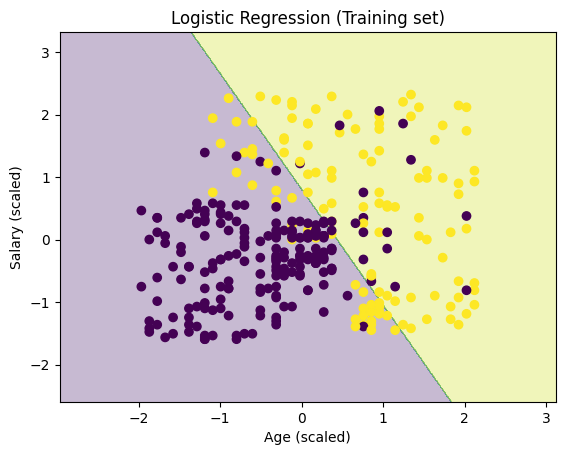

In [7]:
#Please write the code here
import numpy as np

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Salary (scaled)')
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. The logistic regression model uses the sigmoid function to generate probabilities ranging from 0 to 1 that represent the likelihood that a data point belongs to a specific class. A threshold of 0.5 is applied to the probabilities to perform the classification. A data point is classified as 1 (purchased) if the probability is greater than or equal to 0.5 and as 0 (not purchased) if the probability is less than 0.5.
2. Based on the model and visualization of the decision boundary, we understand that older customers with higher salaries are more likely to purchase a car. This is because the model recognizes a pattern in which people with higher incomes and ages are classified as having purchased a car. This makes sense because people with higher incomes and ages are in a better position to purchase a car.
3. There are a number of possible causes that might result in lower accuracy in this model. To begin with, it should be noted that in this dataset, we have only two features: age and salary. This might not be enough to cover all possible aspects that might affect car purchases. Further, it might be possible that classes are overlapping in this dataset; that is, customers might have different purchasing behavior based on age and salary values but still belong to the same class. It might also be possible that noise in the data might affect accuracy. Also, it might be possible that the relation between features and the target variable might not be linear.
4. Accuracy can be improved by adding relevant features, such as gender, credit scores, marital status, and locations. This can be achieved using feature engineering techniques, such as grouping ages into categories or creating income brackets. In terms of data preprocessing, addressing issues like outliers, missing values, and class imbalance can also increase accuracy. Another way to improve accuracy is to use different models, such as decision trees or random forests.